# Proyecto Final

Para mi proyecto final el curso nos pedía realizar un modelo que predecia la lluvia en Australia, sin embargo voy a intentar realizar el mismo modelo pero sobre Argentina, para esto voy  estar utilizando un Dataset de [Kaggle](https://www.kaggle.com) cortesía de [Minahil Fatima](https://www.kaggle.com/minahilfatima12328).<br> En cuanto a los aspectos técnicos, voy a estar utilizando 2 modelos: Random Forest y KNN.

### SETUP
Descargamos e importamos librerias y dataset

In [1]:
!pip install -q kagglehub[pandas-datasets]
!pip install -q numpy
!pip install -q matplotlib
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q seaborn

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


file_path = "Argentina_weather_data.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "minahilfatima12328/argentina-atmospheric-data",
  file_path,
)

/tmp/ipykernel_177348/1370608123.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 483k/483k [00:00<00:00, 664kB/s]


## Estudio del Dataset

Veamos un poco el formato que tiene nuestro dataset y analicemos cuales features son las más adecuadas para la predicción a primera vista.

In [5]:
df.dtypes

Country               object
Date                  object
Temp_Max             float64
Temp_Min             float64
Temp_Mean            float64
Precipitation_Sum    float64
Windspeed_Max        float64
Windgusts_Max        float64
Sunshine_Duration    float64
dtype: object

Obtengamos un pequeño sample

In [10]:
df.head()

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration,rained
0,Argentina,01-01-2000,33.9,20.7,27.5,0.0,17.9,32.8,49047.75,No
1,Argentina,02-01-2000,32.9,22.2,27.3,0.6,23.1,43.6,48969.22,No
2,Argentina,03-01-2000,32.1,21.0,26.9,0.0,20.6,40.7,48921.57,No
3,Argentina,04-01-2000,32.2,20.9,26.7,0.0,25.1,47.2,48091.20,No
4,Argentina,05-01-2000,30.5,21.0,25.7,0.0,23.7,45.4,48922.09,No


Algunas observaciónes importantes son que nuestra temperatura está medida en grados Celsios, la precipitación en mililitros y la duración de la luz solar en segundos.

## Estudio y Preprocesamiento del Dataset

Podemos notar un pequeño problema en el dataset y es que no tenemos una variable binaria de si llovió ese dia o no, por suerte aplicando un poco de _feature engineering_ podemos resolverlo fácilmente. 

In [41]:

def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'



#Pongamos un threshold arbitrario (en este caso pongo 1mm de lluvia, que es lo que usa el dataset de Australia)
threshold = 1




df['rained'] = df['Precipitation_Sum'].apply(lambda x: 'Yes' if x > threshold else 'No')

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df["season"] = df["Date"].apply(date_to_season)
df=df.drop(columns=['Date'])

Con esto resolvemos el problema de nuestra variable objetivo, ahora podemos eliminar ciertos datos redundantes, como por ejemplo el país (dado que únicamente es sobre Argentina), además de eliminar cualquier registro con campos vacíos.

In [42]:
df.dropna()
df.drop(columns=["Country"])

,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration,rained,season
0,33.9,20.7,27.5,0.0,17.9,32.8,49047.75,No,Summer
1,32.9,22.2,27.3,0.6,23.1,43.6,48969.22,No,Summer
2,32.1,21.0,26.9,0.0,20.6,40.7,48921.57,No,Summer
3,32.2,20.9,26.7,0.0,25.1,47.2,48091.20,No,Summer
4,30.5,21.0,25.7,0.0,23.7,45.4,48922.09,No,Summer
...,...,...,...,...,...,...,...,...,...
8761,32.0,15.8,23.7,0.6,27.0,51.8,40577.93,No,Summer
8762,31.3,18.9,25.0,0.0,22.7,45.0,48722.72,No,Summer
8763,25.1,15.3,20.0,0.0,25.9,47.2,49242.36,No,Summer
8764,30.3,13.9,22.4,0.0,19.8,37.8,49097.88,No,Summer


Todavía nos quedan ~8700 registros, que es un buen número para nuestro modelo. <br>

Teniendo estos registros "purificados" podemos ver la distrbiución de valores de nuestra variable objetivo

<Axes: ylabel='count'>

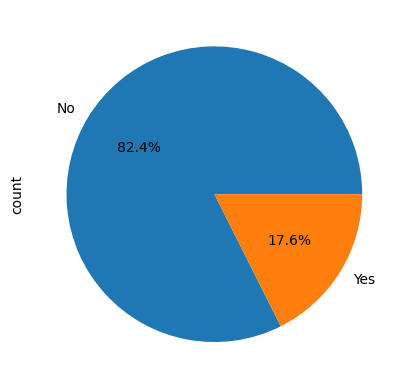

In [43]:
df["rained"].value_counts().plot(kind='pie',  autopct='%1.1f%%')

Podemos notar una gran diferencia en la distrbiución de nuestro target, esto nos podría llevar a un overfitting de casos negativos y underfitting de los positivos. Esto podemos evitarlo en la separación de entrenamiento/validación mediante el _stratify_.

### Procesamiento del Dataset
Ahora definamos features y target, armemos el split entrenamiento/validación y creemos los transformadores según el tipo de dato. 

In [44]:
X = df.drop(columns=["rained","Country","Precipitation_Sum"])
Y = df["rained"]

In [45]:

X_test, X_train, Y_test, Y_train = train_test_split(X,Y, test_size=0.2, random_state=24, stratify=Y)


In [46]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

## Pipeline
Armemos el pipeline, vamos a utilizar  un preprocesador (con los transformadores declarados anteriormente),  un estimador de tipo random forests y por último lo optimizamos mediante cross-validation de los hiperparametros.

Preprocesador:

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Pipeline:

In [48]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


Optimización:

In [49]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True)

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)  
grid_search.fit(X_train, Y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.6s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.6s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Temp_Max',
                                                                          'Temp_Min',
                                                                          'Temp_Mean',
                                                                          'Windspeed_Max',
                                                                          'Windgusts_Max',
                                                                          'Sunshine_Duration']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['season'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

## Análisis de Resultados

In [50]:
y_pred = grid_search.predict(X_test)

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.96      0.92      5779
         Yes       0.70      0.40      0.51      1233

    accuracy                           0.86      7012
   macro avg       0.79      0.68      0.72      7012
weighted avg       0.85      0.86      0.85      7012



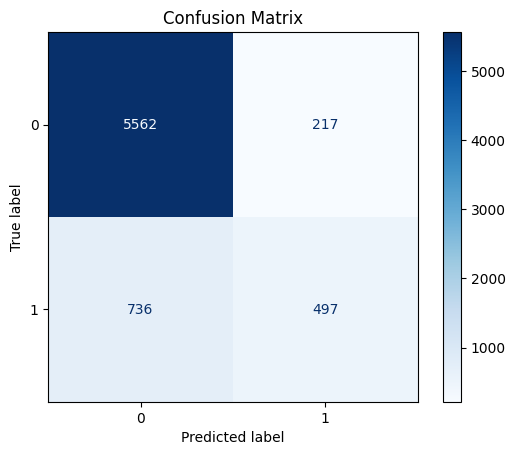

In [51]:
conf_matrix = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()